In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [6]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

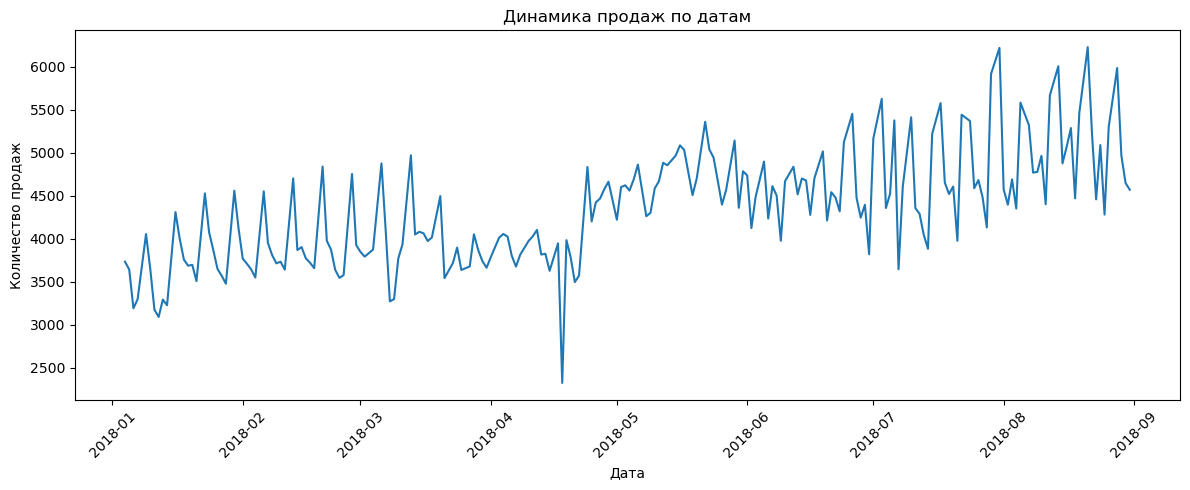

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Динамика продаж по датам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [9]:
# На графике видна динамика количества продаж с января по август 2018 года.
# В начале года продажи в основном находятся примерно в диапазоне 3000-4500 единиц.
# Начиная с мая наблюдается рост среднего уровня продаж.
# В июле–августе значения становятся более волатильными и чаще достигают 5000-6000.
# Также заметен сильный провал примерно в конце апреля это потенциальный выброс.
# В целом наблюдается положительная динамика продаж к концу рассматриваемого периода.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

In [11]:
df['Количество'].max()

200

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [12]:
# Оставляем только июнь, июль и август
summer = df[df['Дата'].dt.month.isin([6, 7, 8])]

# Оставляем только среды
wednesday = summer[summer['Дата'].dt.dayofweek == 2]

# Оставляем только склад 3
warehouse_3 = wednesday[wednesday['Склад'] == 3]

# Считаем продажи по товарам
top_product = (
    warehouse_3
    .groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
)

top_product.head(10)

Номенклатура
product_1     2267
product_2     2060
product_0     1324
product_3      914
product_6      650
product_4      540
product_22     509
product_5      480
product_13     253
product_15     230
Name: Количество, dtype: int64

In [13]:
# Находим самый продаваемый товар и общее количество его продаж
top_product.idxmax(), top_product.max()

('product_1', 2267)

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [16]:
weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [21]:
weather = pd.read_csv(
    'weather_astana.csv',
    sep=';',
    encoding='utf-8',
    skiprows=6,
    index_col=False
)

weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN


In [22]:
# Преобразуем дату и время
weather['Местное время в Астане'] = pd.to_datetime(
    weather['Местное время в Астане'],
    dayfirst=True
)

# Создаем отдельную дату без времени
weather['Дата'] = weather['Местное время в Астане'].dt.normalize()

# Считаем среднюю температуру за каждый день
weather_daily = (
    weather.groupby('Дата')['T']
    .mean()
    .reset_index()
)

weather_daily.head()

,Дата,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625


In [23]:
# Объединяем продажи и среднюю температуру по дате
merged_df = grouped_df.merge(
    weather_daily,
    on='Дата',
    how='left'
)

merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


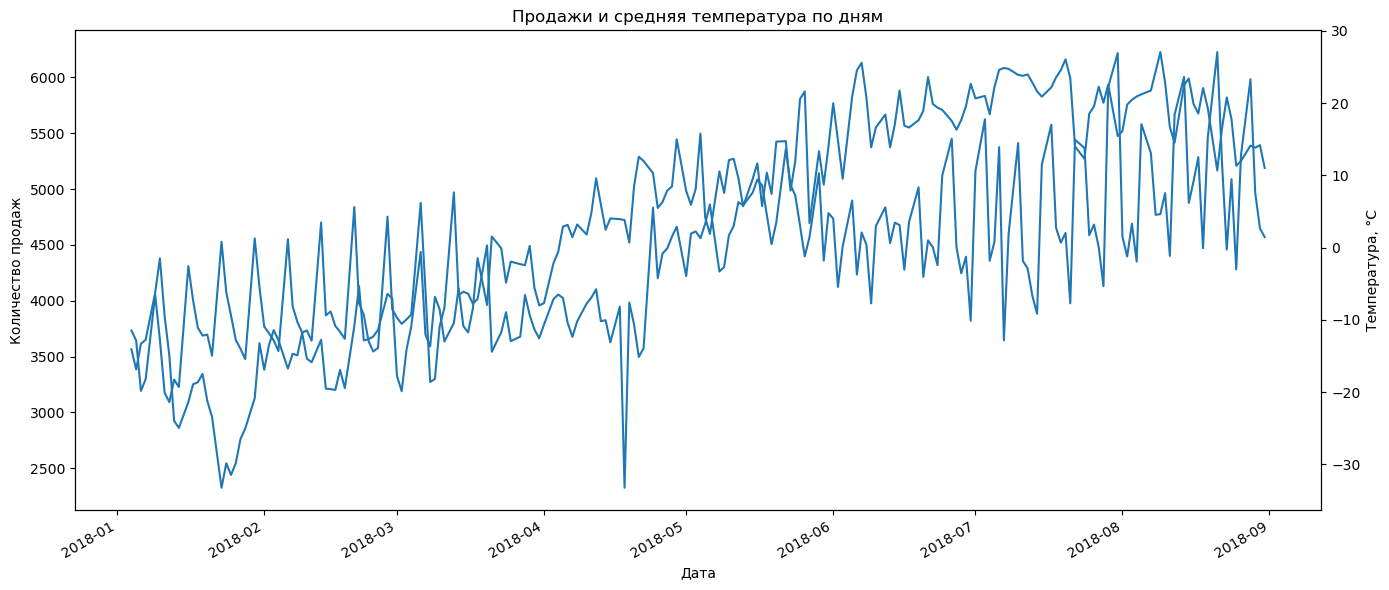

In [24]:
# График продаж и средней температуры по дням

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(merged_df['Дата'], merged_df['Количество'])
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж')

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'])
ax2.set_ylabel('Температура, °C')

plt.title('Продажи и средняя температура по дням')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

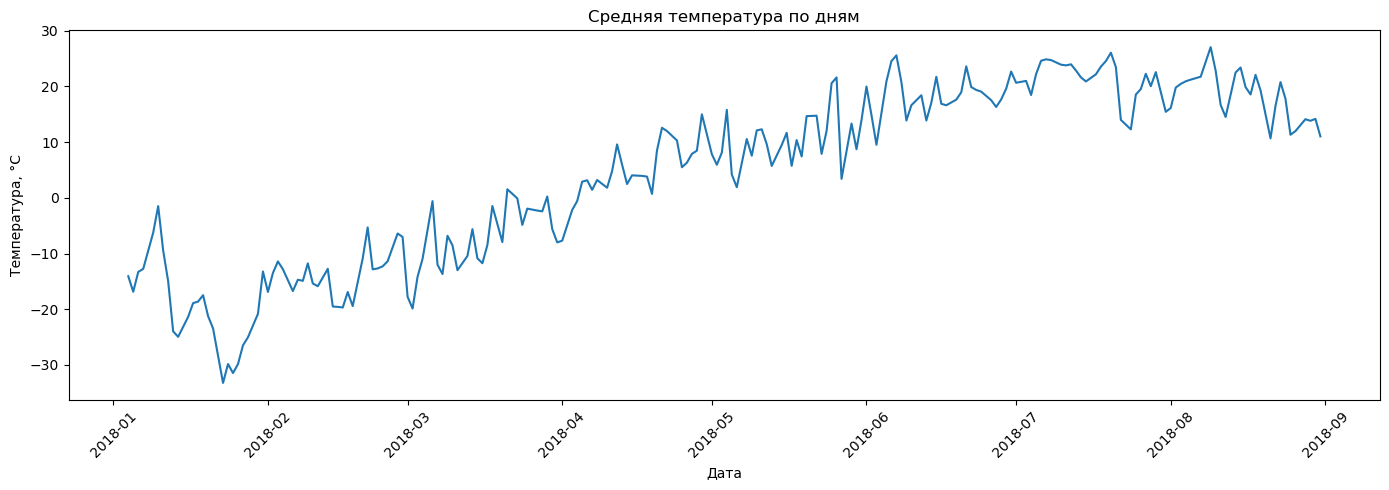

In [25]:
# График средней температуры по дням

plt.figure(figsize=(14, 5))
plt.plot(merged_df['Дата'], merged_df['T'])

plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.title('Средняя температура по дням')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# На графиках видно сезонное повышение температуры от зимы к лету.
# Продажи также в среднем растут к летним месяцам, но имеют заметные колебания.
# Однозначную прямую зависимость между температурой и продажами по графику установить сложно,
# однако в тёплый период средний уровень продаж выше, чем в начале года.